<a href="https://colab.research.google.com/github/yogidharma21/NoLimit-DS-Test-Yogi-Dharma/blob/main/Nolimit_Data_Science_Test_Yogi_Dharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Import Library & Data

In [ ]:
!pip install -U pip

!pip install \
tensorflow\
transformers==4.52.4 \
sentence-transformers \
scikit-learn \
pandas \
numpy \
matplotlib \
seaborn \
wordcloud \
imbalanced-learn \
faiss-cpu \
evaluate \
emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 30.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 22.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 47.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 27.6 MB/s  0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.17.0
    Uninstalling huggingface_hub-1.17.0:
      Successfully uninstalled huggingface_hub-1.17.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.9.0
    Uninstalling transformers-5.9.0:
      Successfully uninstalled transformers-5.9.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [evaluate]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string
import nltk
import emoji
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

import requests
import csv
from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from sentence_transformers import SentenceTransformer
import os

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("alexmariosimanjuntak/dana-app-sentiment-review-on-playstore-indonesia")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'dana-app-sentiment-review-on-playstore-indonesia' dataset.
Path to dataset files: /kaggle/input/dana-app-sentiment-review-on-playstore-indonesia
['review_dana_labelled.csv']


In [ ]:
csv_path = os.path.join(
    path,
    "review_dana_labelled.csv"
)

df = pd.read_csv(csv_path)
df.head()

,userName,score,at,content,sentimen
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   userName  50000 non-null  object
 1   score     50000 non-null  int64 
 2   at        50000 non-null  object
 3   content   50000 non-null  object
 4   sentimen  50000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


## Data Preprocessing

In [ ]:
url = "https://raw.githubusercontent.com/ezaaputra/Sentiment-Analysis-Using-BERT/refs/heads/main/kamus_alay.csv"
slangwords = pd.read_csv(url)
slangwords.head()

,slang,formal
0,woww,wow
1,aminn,amin
2,met,selamat
3,netaas,menetas
4,keberpa,keberapa


In [ ]:
def casefoldingtext(text):
    text = text.lower()
    return text

def cleaningtext(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text)
    text = re.sub(r'#[A-Za-z0-9]+', '', text)
    text = re.sub(r'RT[\s]', '', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[0-9]+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'(\w+)²', r'\1', text)
    text = re.sub(r'\b(\w+)\1\b', r'\1', text)
    text = re.sub(r'(.)\1{2,}', r'\1', text)
    text = " ".join([w for w in text.split() if len(w) > 1])
    text = emoji.demojize(text)
    text = re.sub(':[A-Za-z_-]+:', ' ', text)
    text = re.sub(r"([xX;:]'?[dDpPvVoO3)(])", ' ', text)
    text = text.replace('\n', '')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.strip(' ')
    return text

normalize_word_dict = {}

for _, row in slangwords.iterrows():
    normalize_word_dict[row[0]] = row[1]

def fix_slangwords(text):
    words = word_tokenize(text)

    words = [
        normalize_word_dict[word]
        if word in normalize_word_dict
        else word
        for word in words
    ]

    return " ".join(words)

/tmp/ipykernel_7804/3717972429.py:27: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  normalize_word_dict[row[0]] = row[1]


In [ ]:
teks = "  akuuuu mau      memberi makan gaga tidak berguna      "
tokens = word_tokenize(teks)
print(cleaningtext(teks))

aku mau memberi makan ga tidak berguna


In [ ]:
df['text_casefolding'] = df['content'].apply(casefoldingtext)

df['text_clean'] = df['text_casefolding'].apply(cleaningtext)

df['text_final'] = df['text_clean'].apply(fix_slangwords)

In [ ]:
df.head()

,userName,score,at,content,sentimen,text_casefolding,text_clean,text_final
0,Elisya Kasni,5,2024-02-15 11:24:56,Bagus,POSITIVE,bagus,bagus,bagus
1,Rusman Man,2,2024-02-15 11:24:03,Dana mmg keren mantap.,POSITIVE,dana mmg keren mantap.,dana mmg keren mantap,dana memang keren mantap
2,Qiliw Sadega,1,2024-02-15 11:23:34,Saya ngajuin upgrade dana premium krna ktp say...,NEGATIVE,saya ngajuin upgrade dana premium krna ktp say...,saya ngajuin upgrade dana premium krna ktp say...,saya mengajukan upgrade dana premium karena kt...
3,Kijutjrv2 Kijut,3,2024-02-15 11:22:46,Kocak mana diskon nya ml malah eror segala kag...,NEGATIVE,kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon nya ml malah eror segala kag...,kocak mana diskon nya ml malah eror segala kag...
4,Fifi Alfiyah,1,2024-02-15 11:21:34,Saldo hilang karena no lama Hilang ganti no sa...,NEGATIVE,saldo hilang karena no lama hilang ganti no sa...,saldo hilang karena no lama hilang ganti no sa...,saldo hilang karena no lama hilang ganti no sa...


## EDA

In [ ]:
df['sentimen'].value_counts()

,count
sentimen,
POSITIVE,26555
NEGATIVE,17073
NEUTRAL,6372


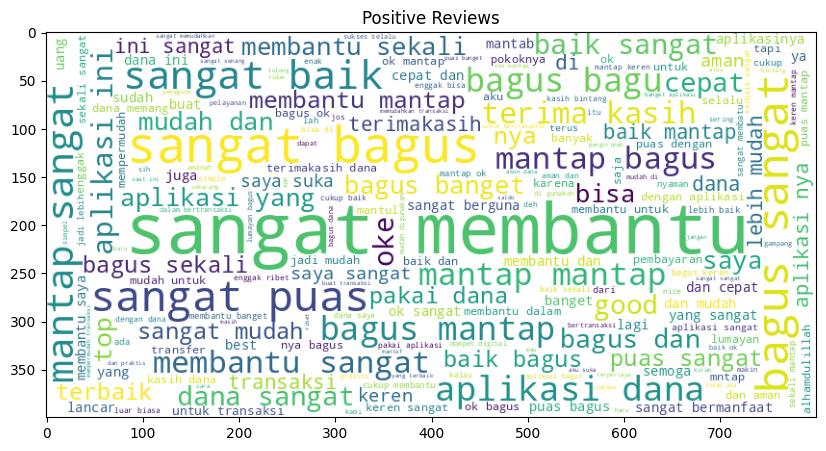

In [ ]:
positive_text = " ".join(
    df[df['sentimen'] == 'POSITIVE']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('Positive Reviews')
plt.show()

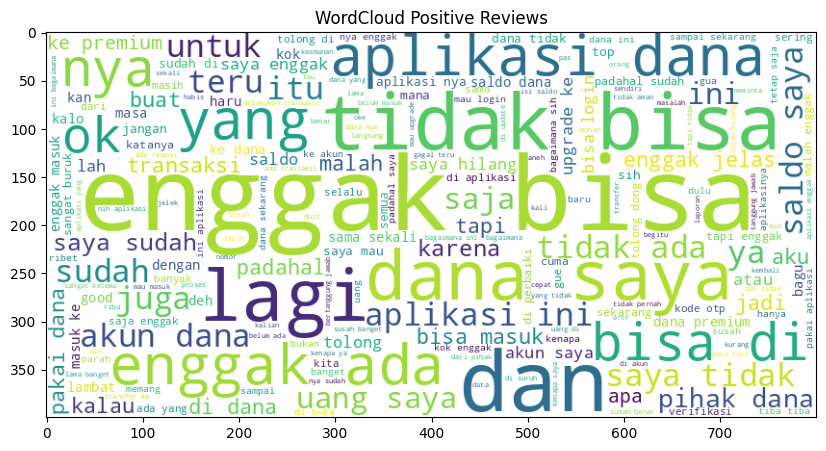

In [ ]:
positive_text = " ".join(
    df[df['sentimen'] == 'NEGATIVE']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('WordCloud Positive Reviews')
plt.show()

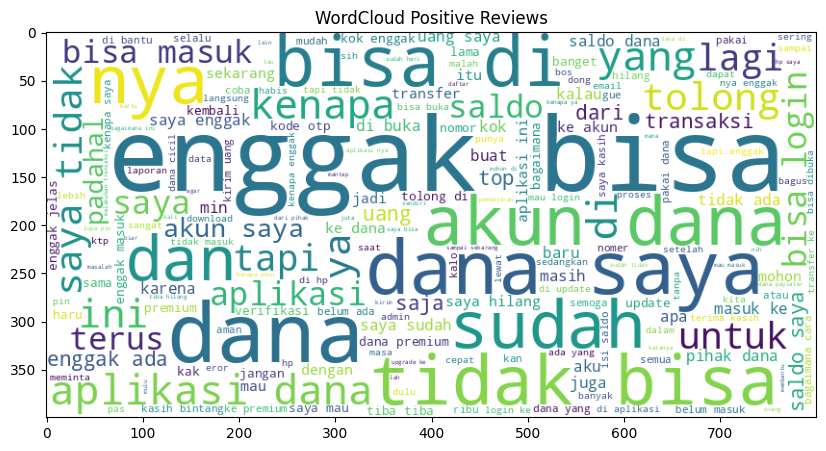

In [ ]:
positive_text = " ".join(
    df[df['sentimen'] == 'NEUTRAL']['text_final']
)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.title('WordCloud Positive Reviews')
plt.show()

## Data Spliting

In [ ]:
X = df["text_final"]
y = df["sentimen"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
le = LabelEncoder()

y_train = le.fit_transform(y_train)

y_test = le.transform(y_test)

In [ ]:
print(dict(zip(
    le.classes_,
    le.transform(le.classes_)
)))

{'NEGATIVE': np.int64(0), 'NEUTRAL': np.int64(1), 'POSITIVE': np.int64(2)}


In [ ]:
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique, counts)))

{np.int64(0): np.int64(13658), np.int64(1): np.int64(5098), np.int64(2): np.int64(21244)}


## Build Model Sentence Transformer


In [ ]:
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.9762288280372919), np.int64(1): np.float64(2.6154047338825683), np.int64(2): np.float64(0.6276281930584322)}


In [ ]:
embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

X_train_emb = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)

X_test_emb = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True,
    normalize_embeddings=True,
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/201 [00:00<?, ?B/s]

Batches:   0%|          | 0/1250 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_train_emb.shape[1],)),

    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(3, activation='softmax')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train_emb,
    y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=64,
    class_weight=class_weights,
    callbacks=[early_stop]
)

Epoch 1/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.7742 - loss: 0.5980 - val_accuracy: 0.7958 - val_loss: 0.5141
Epoch 2/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8001 - loss: 0.5285 - val_accuracy: 0.8115 - val_loss: 0.4705
Epoch 3/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8068 - loss: 0.5132 - val_accuracy: 0.8140 - val_loss: 0.4623
Epoch 4/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8121 - loss: 0.5006 - val_accuracy: 0.8012 - val_loss: 0.4813
Epoch 5/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8160 - loss: 0.4927 - val_accuracy: 0.8120 - val_loss: 0.4562
Epoch 6/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8186 - loss: 0.4848 - val_accuracy: 0.8232 - val_loss: 0.4456
Epoch 7/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8210 - loss: 0.4797 - val_accuracy: 0.8090 - val_loss: 0.4676
Epoch 8/20
563/563 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8217 - loss: 0.4768 - val_accuracy: 

In [ ]:
loss, acc = model.evaluate(
    X_test_emb,
    y_test
)

print("Accuracy:", acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8275 - loss: 0.4248
Accuracy: 0.8274999856948853


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

    NEGATIVE       0.78      0.82      0.80      3415
     NEUTRAL       0.55      0.67      0.61      1274
    POSITIVE       0.95      0.87      0.91      5311

    accuracy                           0.83     10000
   macro avg       0.76      0.79      0.77     10000
weighted avg       0.84      0.83      0.83     10000



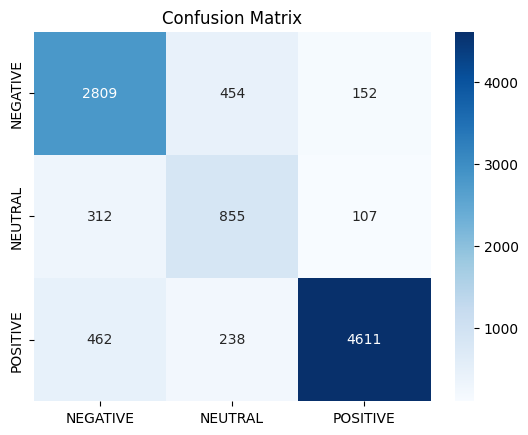

In [ ]:
y_pred = np.argmax(model.predict(X_test_emb), axis=1)

print(classification_report(
    y_test, y_pred,
    target_names=le.classes_
))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

## Similarity Search

In [ ]:
nn = NearestNeighbors(
    n_neighbors=5,
    metric='cosine'
)

nn.fit(X_train_emb)

NearestNeighbors(metric='cosine')

In [ ]:
query = "aplikasi dana sering error saat transfer"

query_emb = embedding_model.encode([query])

distances, indices = nn.kneighbors(query_emb)

In [ ]:
for idx in indices[0]:
    print(X_train.iloc[idx])

kacau aplikasi dana sering bermasalah
sering error dana enggak bisa loginerror lagi
aplikasi dana sekarang parahsering update bukan makin bagus tapi buruk sering error dan keluar terus susah mengirimklaim kiriman daget tolong perbaiki lagiapalagi tiap isi saldo enggak masuk tapi pengiriman sukses nomor dana sudah benar terus dana nya masuk kemana tolong sekali perbaiki yang benar jangan koruptor
aplikasi berat dipakai nya suka erorr dengan alesan jaringan mengirim uang sering banget pending
terlalu sering pending pengiriman padahal uang yang mau dikirim sangat diperlukan oleh keluarga gara kirim pakai dana keluarga saya jadi kelaparan tolong balikin saldonya lagi habis ini uninstal aplikasi dana enggak rekomended merugikan masyarakat


In [ ]:
query = "saldo hilang setelah transaksi"

query_emb = embedding_model.encode([query])

distances, indices = nn.kneighbors(query_emb)

In [ ]:
for idx in indices[0]:
    print(X_train.iloc[idx])

saldo tiba tiba hilang
saldo hilang tanpa transaksi saya sendiri
saldo dana hilang transaksi tidak sah atau di retas
saldo hilang padahal saya tidak melakukan transaksi
saldo hilang tiba tiba


In [ ]:
sample = "aplikasi sangat membantu dan mudah digunakan"

sample_emb = embedding_model.encode([sample])

pred = model.predict(sample_emb)

label = le.inverse_transform(
    [np.argmax(pred)]
)[0]

print("Review :", sample)
print("Prediksi :", label)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step
Review : aplikasi sangat membantu dan mudah digunakan
Prediksi : POSITIVE


## Save Model

In [ ]:
import joblib

joblib.dump(le, "label_encoder.pkl")
joblib.dump(nn, "nearest_neighbors.pkl")

model.save("sentiment_model.keras")

In [ ]:
joblib.dump(
    X_train,
    "reviews.pkl"
)

['reviews.pkl']

In [ ]:
model.save("model.h5")